C:\Users\WINDOWS 10\AppData\Local\Temp\ipykernel_13928\1386084504.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='x_wins', data=df, palette='viridis')
C:\Users\WINDOWS 10\AppData\Local\Temp\ipykernel_13928\1386084504.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_draw', data=df, palette='magma')


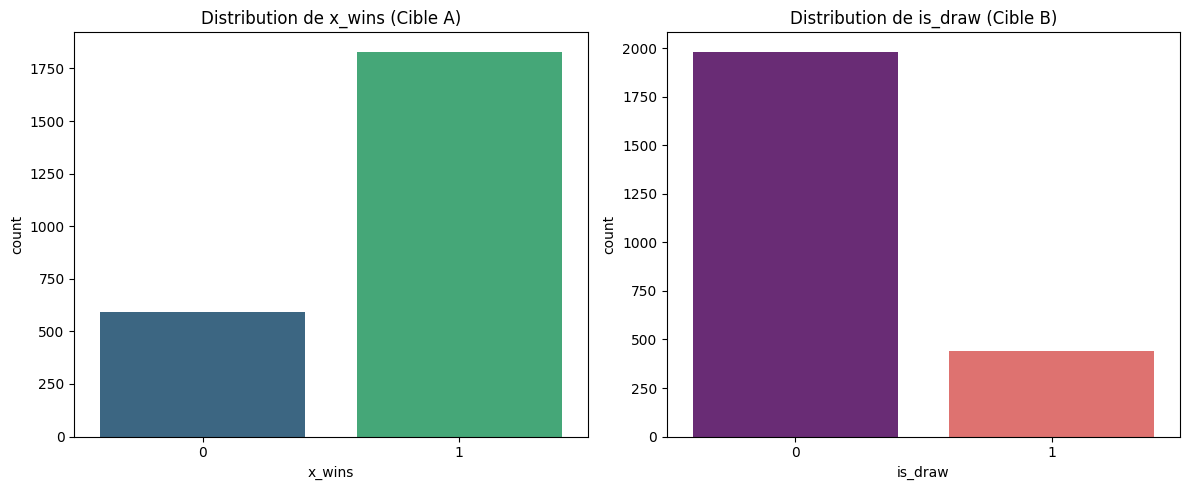

Fréquence d'occupation des cases par X lors d'une victoire :
c4_x    592
c0_x    569
c2_x    569
c8_x    569
c6_x    569
c3_x    521
c1_x    521
c5_x    521
c7_x    521
dtype: int64


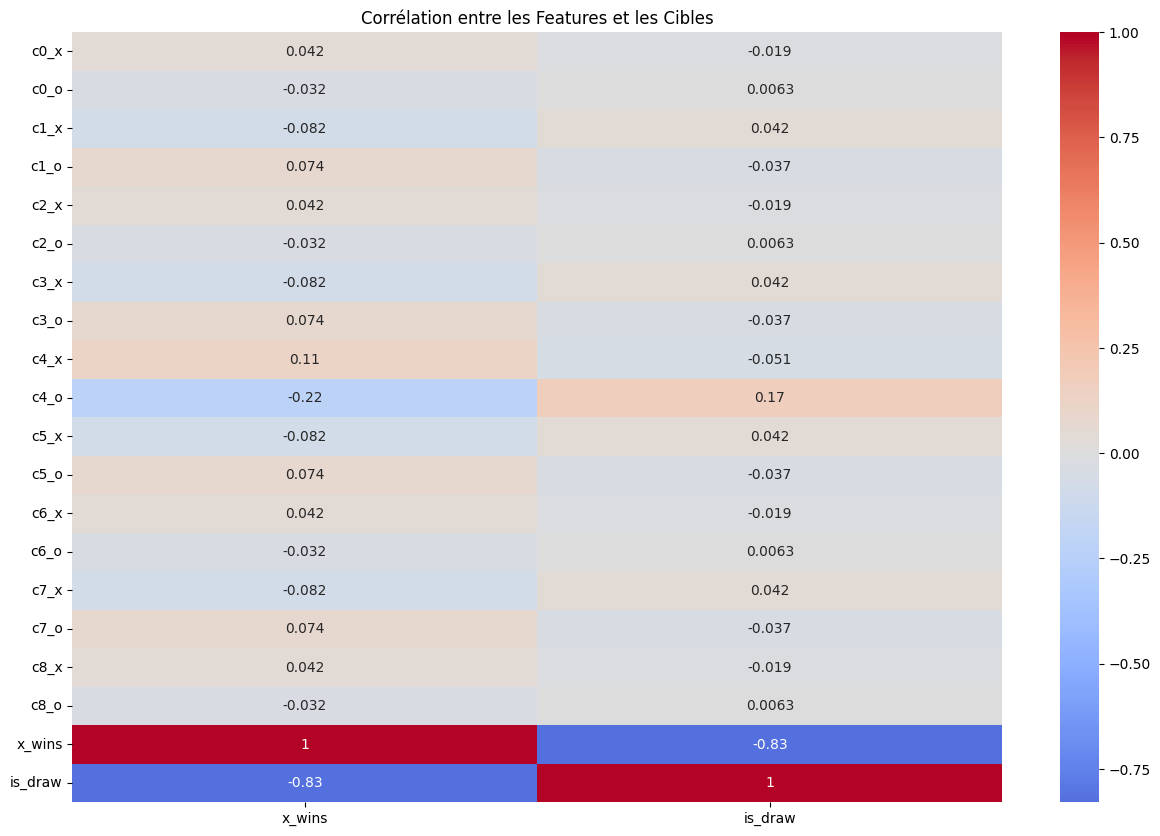

In [14]:
#etape1

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chargement du dataset généré à l'étape précédente
df = pd.read_csv('ressources/dataset.csv')

# 2. Distribution des cibles (Équilibre des classes)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='x_wins', data=df, palette='viridis')
plt.title('Distribution de x_wins (Cible A)')

plt.subplot(1, 2, 2)
sns.countplot(x='is_draw', data=df, palette='magma')
plt.title('Distribution de is_draw (Cible B)')

plt.tight_layout()
plt.show()

# 3. Analyse de la case la plus occupée par X quand il gagne
# On filtre les lignes où x_wins == 1
wins_df = df[df['x_wins'] == 1]
# On somme les colonnes ci_x pour voir quelle case est la plus utilisée
x_columns = [f'c{i}_x' for i in range(9)]
occupancy_wins = wins_df[x_columns].sum().sort_values(ascending=False)

print("Fréquence d'occupation des cases par X lors d'une victoire :")
print(occupancy_wins)

# 4. Heatmap de corrélation
plt.figure(figsize=(15, 10))
correlation_matrix = df.corr()
# On se concentre sur la corrélation avec les cibles
sns.heatmap(correlation_matrix[['x_wins', 'is_draw']], annot=True, cmap='coolwarm', center=0)
plt.title('Corrélation entre les Features et les Cibles')
plt.show()

In [6]:
#etap2 Baseline

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import pandas as pd

# Charger le dataset (vérifiez bien le chemin du fichier)
df = pd.read_csv('ressources/dataset.csv')

# 1. Préparation des données
X = df.drop(columns=['x_wins', 'is_draw'])
y_wins = df['x_wins']
y_draw = df['is_draw']

# Split pour les deux modèles
X_train, X_test, y_wins_train, y_wins_test = train_test_split(X, y_wins, test_size=0.2, random_state=42)
_, _, y_draw_train, y_draw_test = train_test_split(X, y_draw, test_size=0.2, random_state=42)

# 2. Entraînement des modèles
model_wins = LogisticRegression()
model_wins.fit(X_train, y_wins_train)

model_draw = LogisticRegression()
model_draw.fit(X_train, y_draw_train)

# 3. Évaluation
def evaluate(model, X_t, y_t, name):
    preds = model.predict(X_t)
    print(f"--- Évaluation : {name} ---")
    print(f"Accuracy: {accuracy_score(y_t, preds):.4f}")
    print(classification_report(y_t, preds))
    return confusion_matrix(y_t, preds)

cm_wins = evaluate(model_wins, X_test, y_wins_test, "Modèle x_wins")
cm_draw = evaluate(model_draw, X_test, y_draw_test, "Modèle is_draw")

--- Évaluation : Modèle x_wins ---
Accuracy: 0.7546
              precision    recall  f1-score   support

           0       0.60      0.12      0.20       124
           1       0.76      0.97      0.86       361

    accuracy                           0.75       485
   macro avg       0.68      0.55      0.53       485
weighted avg       0.72      0.75      0.69       485

--- Évaluation : Modèle is_draw ---
Accuracy: 0.7918
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       384
           1       0.00      0.00      0.00       101

    accuracy                           0.79       485
   macro avg       0.40      0.50      0.44       485
weighted avg       0.63      0.79      0.70       485



C:\Users\WINDOWS 10\PycharmProjects\generator.py\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\WINDOWS 10\PycharmProjects\generator.py\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\WINDOWS 10\PycharmProjects\generator.py\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

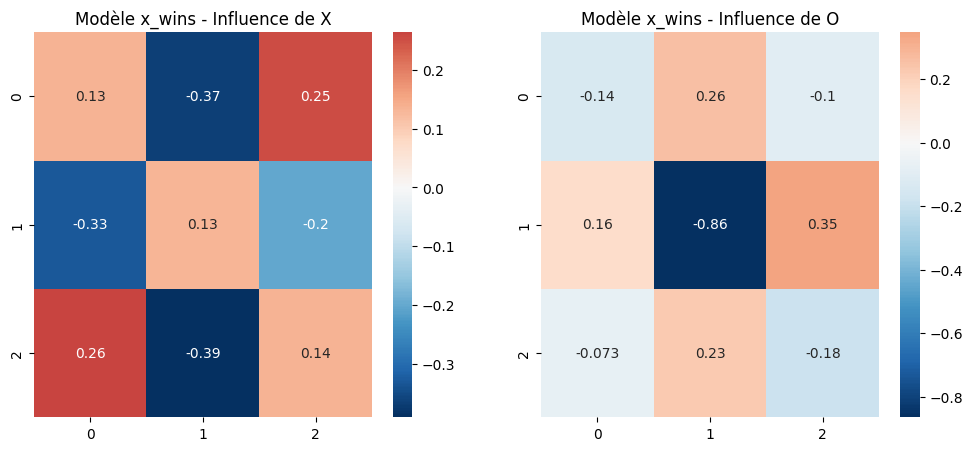

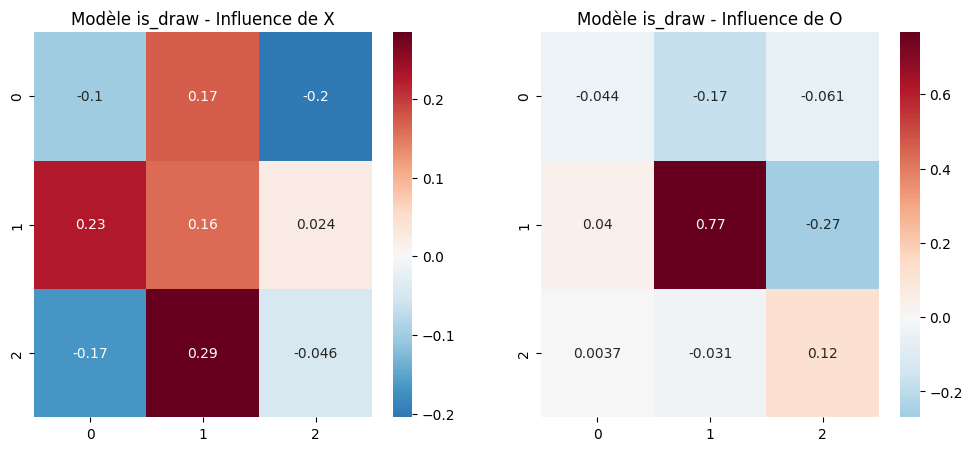

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_coefficients(model, title):
    # Les 18 coefficients (9 pour X, 9 pour O)
    coefs = model.coef_[0]
    coefs_x = coefs[0::2].reshape(3, 3)
    coefs_o = coefs[1::2].reshape(3, 3)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(coefs_x, annot=True, cmap='RdBu_r', center=0, ax=ax1)
    ax1.set_title(f'{title} - Influence de X')

    sns.heatmap(coefs_o, annot=True, cmap='RdBu_r', center=0, ax=ax2)
    ax2.set_title(f'{title} - Influence de O')

    plt.show()

# Maintenant l'appel fonctionnera
plot_coefficients(model_wins, "Modèle x_wins")
plot_coefficients(model_draw, "Modèle is_draw")

In [11]:
from sklearn.ensemble import RandomForestClassifier

# 1. Entraînement pour x_wins
model_rf_wins = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_rf_wins.fit(X_train, y_wins_train)

# 2. Entraînement pour is_draw
model_rf_draw = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_rf_draw.fit(X_train, y_draw_train)

# 3. Évaluation comparée
print("--- PERFORMANCE RANDOM FOREST ---")
evaluate(model_rf_wins, X_test, y_wins_test, "Random Forest x_wins")
evaluate(model_rf_draw, X_test, y_draw_test, "Random Forest is_draw")

--- PERFORMANCE RANDOM FOREST ---
--- Évaluation : Random Forest x_wins ---
Accuracy: 0.8454
              precision    recall  f1-score   support

           0       1.00      0.40      0.57       124
           1       0.83      1.00      0.91       361

    accuracy                           0.85       485
   macro avg       0.91      0.70      0.74       485
weighted avg       0.87      0.85      0.82       485

--- Évaluation : Random Forest is_draw ---
Accuracy: 0.8474
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       384
           1       0.97      0.28      0.43       101

    accuracy                           0.85       485
   macro avg       0.90      0.64      0.67       485
weighted avg       0.87      0.85      0.81       485



array([[383,   1],
       [ 73,  28]])

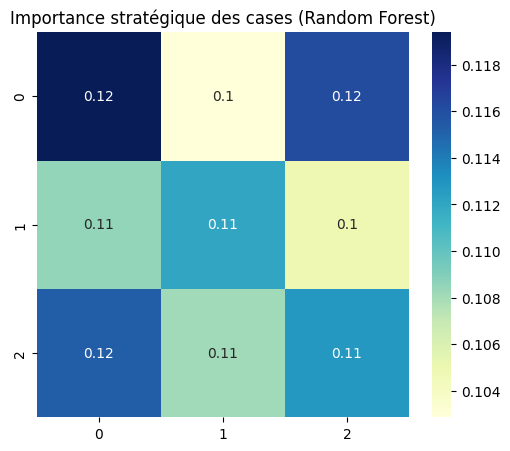

In [12]:
# Visualisation de l'importance des cases
importances = model_rf_wins.feature_importances_
# On regroupe l'importance de (X et O) pour chaque case
case_importance = []
for i in range(0, 18, 2):
    case_importance.append(importances[i] + importances[i+1])

case_importance_grid = np.array(case_importance).reshape(3, 3)

plt.figure(figsize=(6, 5))
sns.heatmap(case_importance_grid, annot=True, cmap='YlGnBu')
plt.title('Importance stratégique des cases (Random Forest)')
plt.show()

In [13]:
import joblib
import os

if not os.path.exists('models'):
    os.makedirs('models')

# Sauvegarde des meilleurs modèles
joblib.dump(model_rf_wins, 'models/best_model_wins.pkl')
joblib.dump(model_rf_draw, 'models/best_model_draw.pkl')
print("Modèles sauvegardés dans le dossier 'models/'")

Modèles sauvegardés dans le dossier 'models/'
